In [8]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# Period of ERA5 used

In [9]:
iyear=1960
fyear=2025

# Domain 

In [10]:
dom='MA' # Middle Asia

# Atmospheric Circulation loading

In [11]:
#load eastward (u) and northward (v) of IVT
uivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/uivt_monthly_era5_1940-2025_NH_025x025.nc')
uivt = uivt.sel(valid_time=slice(f"{iyear}-01-01", f"{fyear}-12-31")) # only during the period wanted

vivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/vivt_monthly_era5_1940-2025_NH_025x025.nc')
vivt = vivt.sel(valid_time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

#load tcwv
tcwv = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/tcwv_monthly_era5_1940-2025_NH_025x025.nc')
tcwv = tcwv.sel(valid_time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

#focus on Middle Asia (MA)
uivt_MA = field_dom(uivt,dom)
vivt_MA = field_dom(vivt,dom)
tcwv_MA = field_dom(tcwv,dom)

# Climatology of atmospheric circulation

In [12]:
# season definition : DJFM (winter), AM (pre-monsoon), JJAS (monsoon), ON (post-monsoon)
seasons = ["DJFM", "AM", "JJAS", "ON"]

# period wanted
start_year = iyear
end_year = fyear

# dictionnary to store tcwv climatology
clim_dict = {}

# dictionnary to store uIVT & vIVT climatology
u_clim_dict = {}
v_clim_dict = {}

# rename time dimension for 'clim' function
tcwv_MA = tcwv_MA.rename({'valid_time': 'time'})
uivt_MA = uivt_MA.rename({'valid_time': 'time'})
vivt_MA = vivt_MA.rename({'valid_time': 'time'})

# climatology for each season for tcwv, uIVT, vIVT
for season in seasons:
    clim_season = clim(tcwv_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year) # function : a particular season + mean
    clim_dict[season] = clim_season
    
    u_clim_season = clim(uivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    u_clim_dict[season] = u_clim_season
    
    v_clim_season = clim(vivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    v_clim_dict[season] = v_clim_season

# Seasonal trends of atmospheric circulation

In [14]:
# other definition for seasons for seasonal_selection2 function
seasons = {"DJFM": [12,1,2,3], 
           "AM": [4,5], 
           "JJAS": [6,7,8,9], 
           "ON": [10,11]}

# period wanted
start_year = iyear
end_year = fyear

# dictionnary to store tcwv trends
trend_dict = {}
p_dict = {} # for the p-value of the trends

# dictionnary to store uIVT & vIVT trends
u_trend_dict = {}
u_p_dict = {} # for the p-value of the trends
v_trend_dict = {}
v_p_dict = {} # for the p-value of the trends

# trends for each season
for season in seasons:
    
    # TCWV
    tcwv_season = seasonal_selection2(tcwv_MA['tcwv'], seasons[season], iyear, fyear) # seasonal selection
    par = trend_vect(tcwv_season.time,tcwv_season,dim='time') # function : linear trend over the period wanted
    trend_season = par[0]*10;p_season = par[3] # slope * 10 -> per decade 
    trend_dict[season] = trend_season
    p_dict[season] = p_season

    # uIVT
    uivt_season = seasonal_selection2(uivt_MA['viwve'], seasons[season], iyear, fyear)
    u_par = trend_vect(uivt_season.time,uivt_season,dim='time')
    u_trend_season = u_par[0]*10;u_p_season = u_par[3]
    u_trend_dict[season] = u_trend_season
    u_p_dict[season] = u_p_season

    # vIVT
    vivt_season = seasonal_selection2(vivt_MA['viwvn'], seasons[season], iyear, fyear)
    v_par = trend_vect(vivt_season.time,vivt_season,dim='time')
    v_trend_season = v_par[0]*10;v_p_season = v_par[3]
    v_trend_dict[season] = v_trend_season
    v_p_dict[season] = v_p_season

# Converting to percentage trends

In [15]:
# dictionnary to store
trend_percentage_dict = {} # TCWV

for season in seasons:
    trend_percentage_dict[season] = (trend_dict[season] / clim_dict[season]) * 100 # in %/decade

# Plot of seasonal trends of atmospheric circulation over Middle Asia 

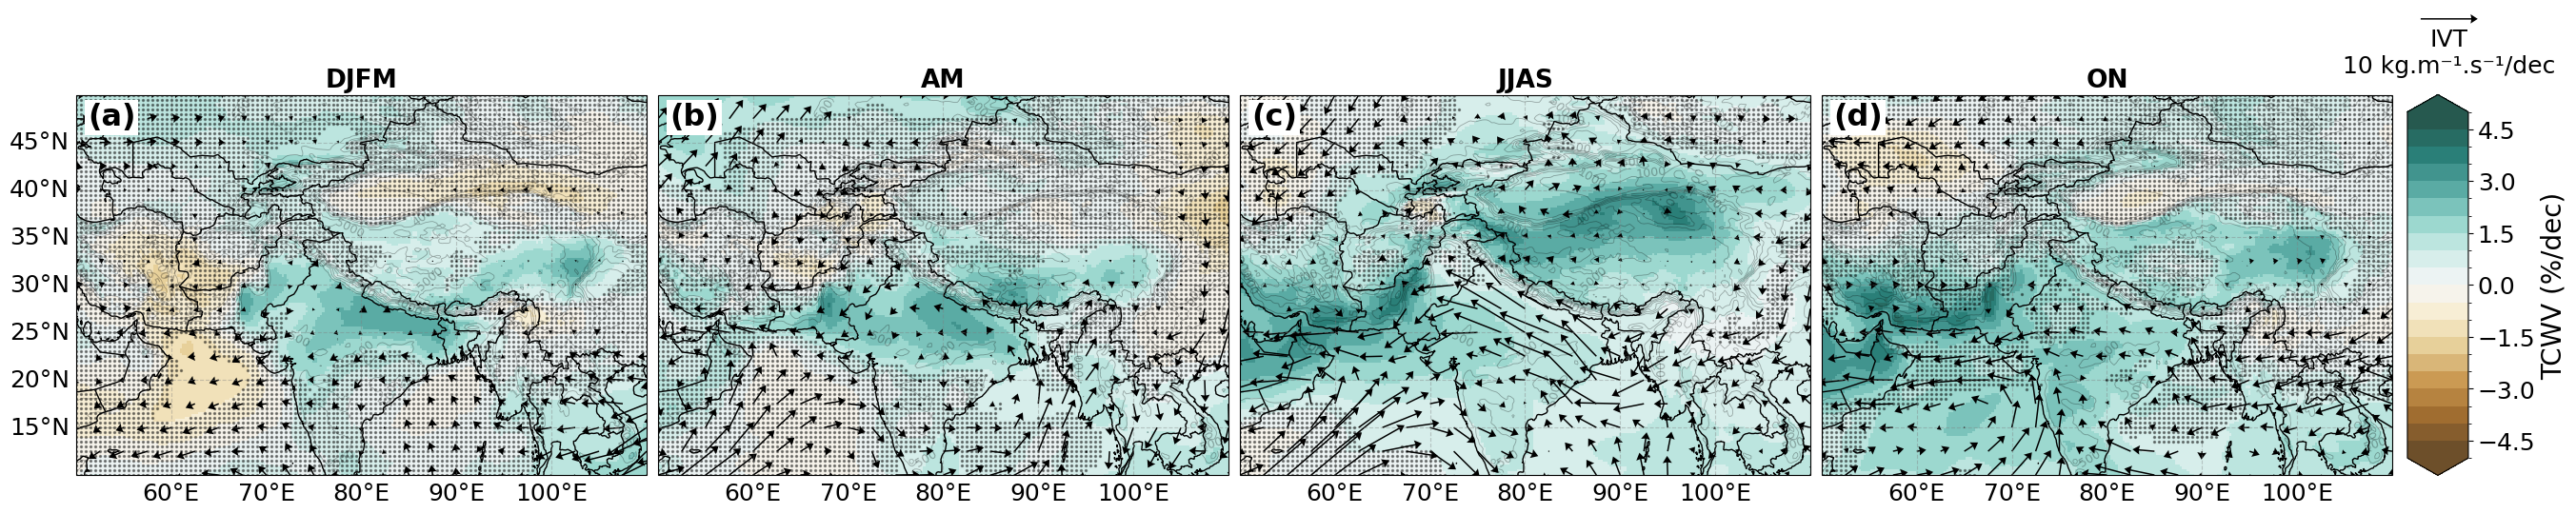

In [17]:
seasons = ["DJFM","AM","JJAS","ON"] # back to the classic definition

# elevation for courbe de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

# colorgrading for tcwv (brown to blue shading), same for every season
step = 0.5
vmax = 5
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("BrBG", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

# letters for the subplots
letters = ['a', 'b', 'c', 'd']

# figure
fig, axes = plt.subplots(1, 4, figsize=(32, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_percentage_dict[season]['tcwv']

    # map of seasonal tcwv with blue shading
    im = ax.pcolormesh(data_season['longitude'],data_season['latitude'],data_season,transform=ccrs.PlateCarree(),
                       cmap=cmap,norm=norm,shading="auto", alpha=0.85)


    # map limitations (not exactly middle asia, smaller)
    ax.set_extent([float(50),float(110),float(10),float(50)], crs=ccrs.PlateCarree())

    # scatter plot for statistical significance (p-value < 0. 05)
    sig = p_dict[season] > 0.05 # p > 0.05 = non significant
    step = 2 # tous les deux points
    lon_sig, lat_sig = data_season['longitude'].values, data_season['latitude'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    # seasonal trends IVT vectors with uIVT & vIVT
    step = 10 # not every vector so that there isn't too much
    u_plot = u_trend_dict[season][::step, ::step] # step on uIVT
    v_plot = v_trend_dict[season][::step, ::step] # step on uIVT
    q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=100,width=0.0025,headwidth=6.5
             ,rasterized=True, color='black') # map of the IVT vectors 

    # coastline and borders
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    # courbe de niveau
    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,1500,2000,2500,3000,4000,5000,6000,7000],
                    colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d") # label des courbes de niveau
    
    ax.set_title(season, fontsize=19, weight="bold") # label des saisons pour les subplots

    # grid for lon et lat (labels only on left and bottom)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i == 0)
    gl.bottom_labels = True
    gl.xlabel_style = {"size": 18}
    gl.ylabel_style = {"size": 18}

    # letter for the subplot top-left
    ax.text(0.02, 0.98,f'({letters[i]})',transform=ax.transAxes,fontsize=23,fontweight='bold',va='top',ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2), zorder=15)

# colorbar for tcwv (brown to blue shading)
cbar_ax = fig.add_axes([0.845, 0.15, 0.02, 0.4]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical", extend='both')
cbar.set_label("TCWV (%/dec)", fontsize=20)
cbar.ax.tick_params(labelsize=18)

# legend for IVT vectors
axkey = fig.add_axes([0.84, 0.58, 0.05, 0.06], frameon=False) # create a small invisible axis in the upper-right corner of the figure
axkey.set_axis_off()
axkey.quiverkey(q,1.1, 1.2, 10,"IVT\n10 kg.m⁻¹.s⁻¹/dec",coordinates='axes',labelpos='S',fontproperties={'size': 18})

fig.subplots_adjust(left=0.08, right=0.84, top=0.82, bottom=-0.12, wspace=0.02, hspace=0)
plt.show()

# Precipitation data loading

### Precipitation domain for HMA only and not MA

In [18]:
dom='HMA'
latS,latN,lonW,lonE = coord_domain(dom)

In [19]:
# ERA5 (1960-2025)
tp1 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1940-2025_ERA5.nc')['tp']
tp1 = field_dom(tp1, dom) # focus on HMA
tp1 = tp1.sel(time=slice(str(iyear),str(fyear))) # focus on the period wanted 1960-2025

# CHIRPS (1981-2024)
tp2 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1981-2025_CHIRPS.nc')['tp']
tp2 = field_dom(tp2, dom)
tp2 = tp2.sel(time=slice(str(1981),str(2024))) # fovus on the period available for CHIRPS 1981-2024

# Climatology of precipitation

In [20]:
# season definition : DJFM (winter), AM (pre-monsoon), JJAS (monsoon), ON (post-monsoon)
seasons = ["DJFM","AM","JJAS","ON"]

# ERA5
tp1_dict = {} # dictionnary to store precipitation climatology ERA5
for season in seasons:
    tp1_season = clim(tp1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
    tp1_dict[season] = tp1_season

# CHIRPS
tp2_dict = {} # dictionnary to store precipitation climatology CHIRPS
for season in seasons:
    tp2_season = clim(tp2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
    tp2_dict[season] = tp2_season

# Seasonal trends of precipitation

In [21]:
# other definition for seasons for seasonal_selection2 function
seasons = {"DJFM": [12,1,2,3], 
           "AM": [4,5], 
           "JJAS": [6,7,8,9], 
           "ON": [10,11]}

# dictionnary to store precipitation trends
# ERA5
trend1_dict = {}
p1_dict={} # for the p-value of the trends
# CHIRPS
trend2_dict = {}
p2_dict={} 

for season in seasons:
    
    # ERA5 (1960-2025)
    tp_season1 = seasonal_selection2(tp1, seasons[season], iyear, fyear) # seasonal selection
    par1 = trend_vect(tp_season1.time, tp_season1, dim='time') # trend on the period wanted
    trend1=par1[0]*10; p1=par1[3] # slope * 10 -> per decade
    trend1_dict[season]=trend1
    p1_dict[season]=p1

    # CHIRPS (1981-2024)
    tp_season2 = seasonal_selection2(tp2, seasons[season], iyear, fyear) # seasonal selection
    par2 = trend_vect(tp_season2.time, tp_season2, dim='time') # trend on the period wanted
    trend2=par2[0]*10; p2=par2[3] # slope * 10 -> per decade
    trend2_dict[season]=trend2
    p2_dict[season]=p2

# Converting to percentage trends

In [22]:
seasons = ["DJFM","AM","JJAS","ON"] # back to the classic definition

# dictionnary to store precipitation percentage trends
trend_percentage_dict1 = {} # ERA5
trend_percentage_dict2 = {} # CHIRPS

for season in seasons:
    # ERA5
    trend_percentage_dict1[season] = (trend1_dict[season] / tp1_dict[season]).where(tp1_dict[season] != 0) * 100 # vérifier si clim != 0
    # CHIRPS
    trend_percentage_dict2[season] = (trend2_dict[season] / tp2_dict[season]).where(tp2_dict[season] != 0) * 100 

# Plot of seasonal trends of precipitation over High Mountain Asia

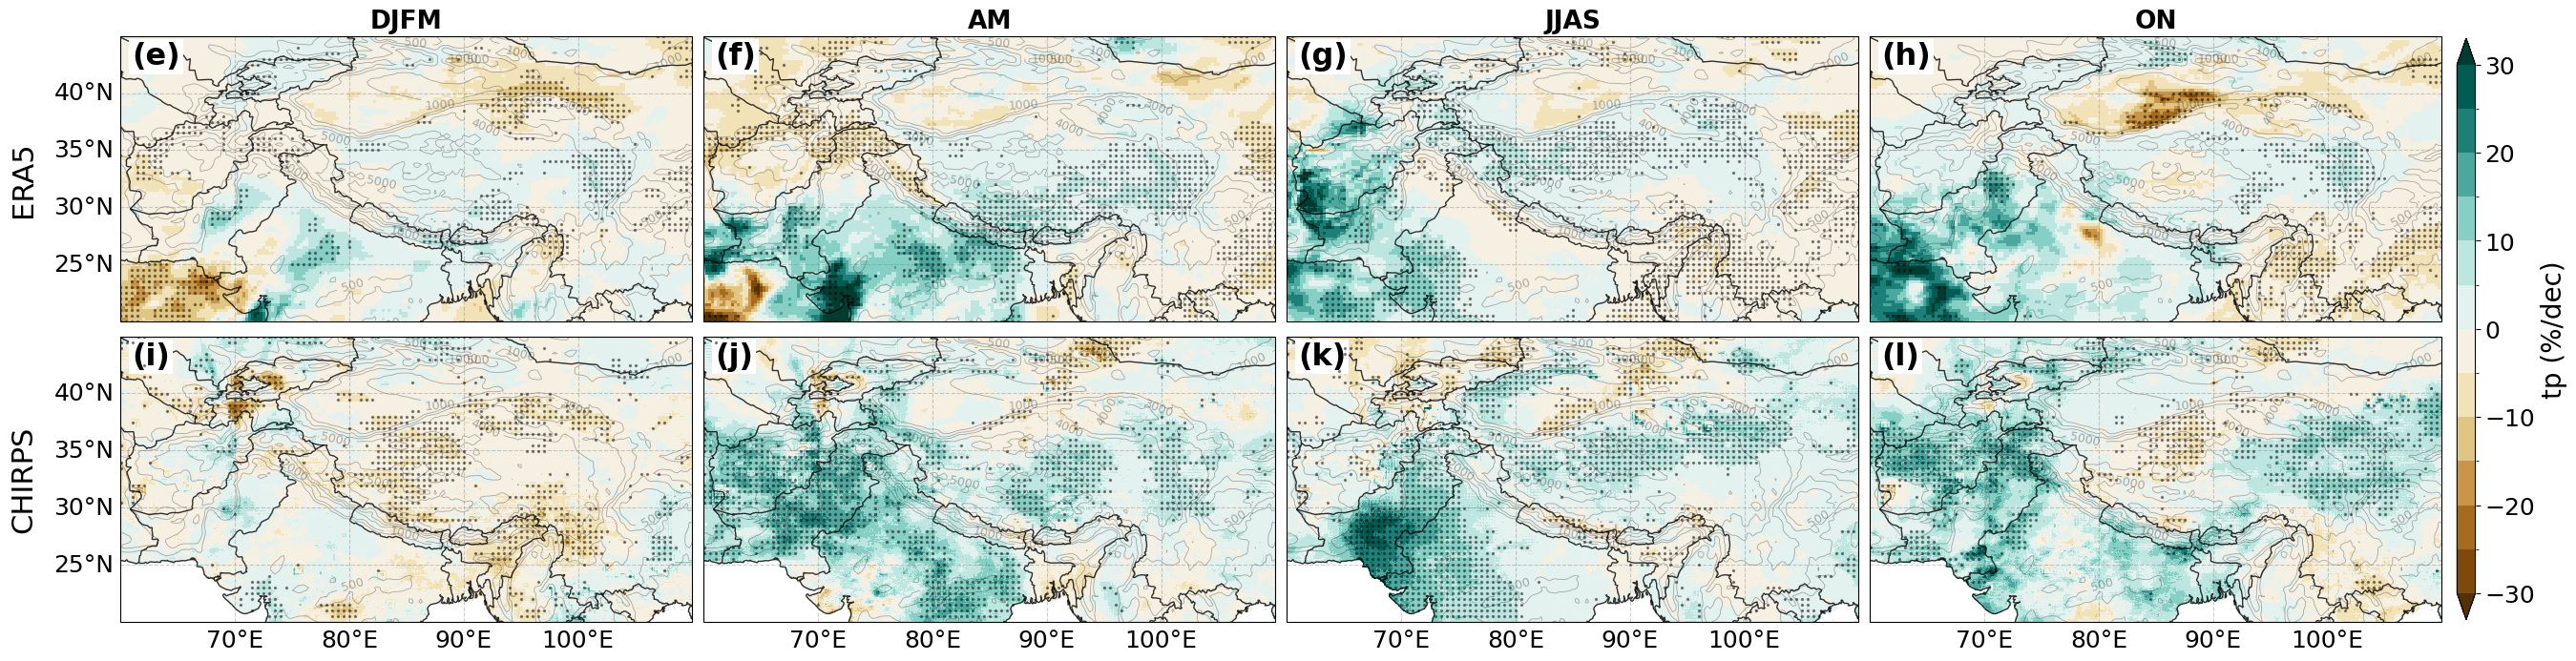

In [23]:
# colorgrading for precipitation (tp), same for every season
step = 5
vmax = 30
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
cmap = cmap.copy()         # permet de modifier
cmap.set_bad(color='white')  # les NaN apparaissent en blanc (not mandatory)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

# letters for the subplots
letters = ['e', 'f', 'g', 'h', 'i', 'j', 'k', 'l']

# figure
fig, axes = plt.subplots(2, 4, figsize=(32, 6.7), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i in [0,1,2,3]:
        season = seasons[i]
    if i in [4,5,6,7]:
        season = seasons[i-4]

    if i in [0,1,2,3]:
        data_season = trend_percentage_dict1[season]
    if i in [4,5,6,7]:
        data_season = trend_percentage_dict2[season]
    
    # map of seasonal precipitation with blue shading
    im = ax.pcolormesh(data_season['lon'], data_season['lat'], data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    # scatter plot for statistical significance (p-value < 0. 05)
    if i in [0,1,2,3]: # ERA5
        sig = p1_dict[season] < 0.05 # p < 0.05 = significant
        step = 2
    if i in [4,5,6,7]: # CHIRPS
        sig = p2_dict[season] < 0.05 # p < 0.05 = significant
        step = 10
    lon_sig, lat_sig = data_season['lon'].values, data_season['lat'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    # map limitations (HMA)
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    # coastline and borders
    ax.add_feature(cfeature.COASTLINE, linewidth=1,alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-",alpha=0.8)

    # courbe de niveau
    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                    colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d") # label des courbes de niveau

    if i in [0,1,2,3]:
        ax.set_title(season, fontsize=19, weight="bold") # label des saisons pour les subplots

    # grid for lon et lat (labels only on left and bottom)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    if i in [0,4]:
        gl.left_labels = True
    else:
        gl.left_labels = False
    if i in [4,5,6,7]:
        gl.bottom_labels = True
    else:
        gl.bottom_labels = False
    gl.xlabel_style = {"size": 18}
    gl.ylabel_style = {"size": 18}

    # letter for the subplot top-left
    ax.text(0.02, 0.98,f'({letters[i]})',transform=ax.transAxes,fontsize=23,fontweight='bold',va='top',ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2))

# colorbar for precipitation (blue shading)
cbar_ax = fig.add_axes([0.845, -0.105, 0.006, 0.91]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical", extend='both')
cbar.set_label("tp (%/dec)", fontsize=20)
cbar.ax.tick_params(labelsize=18)

# labels des lignes (datasets)
axes[0].text(-0.17, 0.5, "ERA5",transform=axes[0].transAxes,fontsize=22,va="center", ha="center",rotation=90) # ERA5
axes[4].text(-0.17, 0.5, "CHIRPS",transform=axes[4].transAxes,fontsize=22,va="center", ha="center",rotation=90) # CHIRPS

fig.subplots_adjust(left=0.08, right=0.84, top=0.82, bottom=-0.12, wspace=0.02, hspace=0)
plt.show()

Figure 6. Seasonal trends of Atmospheric Circulation and Precipitation (1960-2025) : (a-d) Data is from ERA5 (1960-2025). TCWV : Total Column of Water Vapor in %.dec-1, IVT : Integrated water Vapor Transport in kg.m-1.s-1.dec-1. Statistically non significant trends (p > 0.05) are indicated by black dots. (e-l) Precipitation (tp, mm.month-1) is from ERA5 (1960-2025) (e-h) and CHIRPS (1981-20214). (i-l) Statistically significant trends (p < 0.05) are indicated by black dots. The red boxes represent the subregions we defined (see Fig. 2). Topography of ERA5 is shown in contour lines. Black lines denote political borders. 